# Tutorial 6 - Eigenvalue Methods & SVD

---

## 1. Eigenvalues and Eigenvectors

Given a square matrix $A \in \mathbb{R}^{n \times n}$, a scalar $\lambda$ and nonzero vector $v$ are an **eigenvalue–eigenvector pair** if:

$$A v = \lambda v$$

Rearranging: $(A - \lambda I) v = 0$, which has a non-trivial solution iff $\det(A - \lambda I) = 0$ - the **characteristic equation**.

### Why eigenvalues matter
- **Stability analysis** of dynamical systems ($y' = Ay$): solution decays iff $\text{Re}(\lambda_i) < 0$
- **Principal component analysis (PCA)** in geophysics and data science
- **Vibration modes** in structural mechanics
- **Spectral methods** for PDEs
- The **condition number** $\kappa(A) = \lambda_{\max}/\lambda_{\min}$ governs linear solver accuracy

### Diagonalization
If $A$ has $n$ linearly independent eigenvectors $v_1, \ldots, v_n$:
$$A = V \Lambda V^{-1}, \quad \Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$$

For **symmetric** matrices ($A = A^T$): all eigenvalues are real, eigenvectors are orthonormal → $A = Q \Lambda Q^T$ (spectral theorem).

In [1]:
import sys, math
sys.path.insert(0, '../')
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from numethods.linalg import Matrix, Vector
from numethods.eigen import (
    PowerIteration,
    InversePowerIteration,
    RayleighQuotientIteration,
    QREigenvalues,
    SVD,
)

print("numethods eigen module loaded.")

numethods eigen module loaded.


## 2. Power Iteration

**Power iteration** finds the **dominant** (largest-magnitude) eigenvalue.

### Algorithm

Starting from a random $x^{(0)}$:
$$x^{(k+1)} = \frac{A x^{(k)}}{\|A x^{(k)}\|_2}$$

The Rayleigh quotient gives the eigenvalue estimate:
$$\lambda^{(k)} = \frac{(x^{(k)})^T A x^{(k)}}{(x^{(k)})^T x^{(k)}}$$

### Convergence rate
$$\text{error at step } k \sim \left|\frac{\lambda_2}{\lambda_1}\right|^k$$

Convergence is slow when $|\lambda_2/\lambda_1| \approx 1$ (two eigenvalues are close in magnitude).

### Implementation notes (`numethods`)
- Class: `PowerIteration(A, tol, max_iter)`
- Method: `.solve(x0=None)` → returns `(eigenvalue, eigenvector)`
- Method: `.trace()` prints the iteration history

In [2]:
# Example: 3x3 symmetric positive definite matrix
A = Matrix([[6, 2, 1],
            [2, 3, 1],
            [1, 1, 1]])

pi_solver = PowerIteration(A, tol=1e-10, max_iter=500)
lam, v = pi_solver.solve()

print(f"Dominant eigenvalue: λ₁ ≈ {lam:.8f}")
print(f"Eigenvector:         v ≈ {[round(vi, 6) for vi in v.data]}")

# Verification: A*v should equal lambda*v
Av = A @ v
lv = lam * v
print("\nVerification (A·v = λ·v):")
print(f"  A·v = {[round(x,6) for x in Av.data]}")
print(f"  λ·v = {[round(x,6) for x in lv.data]}")
err = max(abs(a-b) for a,b in zip(Av.data, lv.data))
print(f"  max |A·v - λ·v| = {err:.2e}")

Dominant eigenvalue: λ₁ ≈ 7.28799214
Eigenvector:         v ≈ [0.866431, 0.453059, 0.209843]

Verification (A·v = λ·v):
  A·v = [6.314549, 3.301883, 1.529334]
  λ·v = [6.314545, 3.301891, 1.529336]
  max |A·v - λ·v| = 7.73e-06


In [5]:
# Convergence plot
pi_solver2 = PowerIteration(A, tol=1e-14, max_iter=100)
lam2, _ = pi_solver2.solve()

iters = [h['iter'] for h in pi_solver2.history]
errors = [h['error'] for h in pi_solver2.history]

plt.figure(figsize=(8, 4))
plt.semilogy(iters, errors, 'b-o', markersize=4, linewidth=1.5)
plt.xlabel("Iteration $k$")
plt.ylabel(r"$|\lambda^{(k)} - \lambda^{(k-1)}|$  (log scale)")
plt.title("Power Iteration Convergence")
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('power_iter_convergence.png', dpi=100, bbox_inches='tight')
plt.close()
print(f"Converged in {len(iters)} iterations")
print("Check: convergence rate = |λ₂/λ₁| each step")

Converged in 14 iterations
Check: convergence rate = |λ₂/λ₁| each step


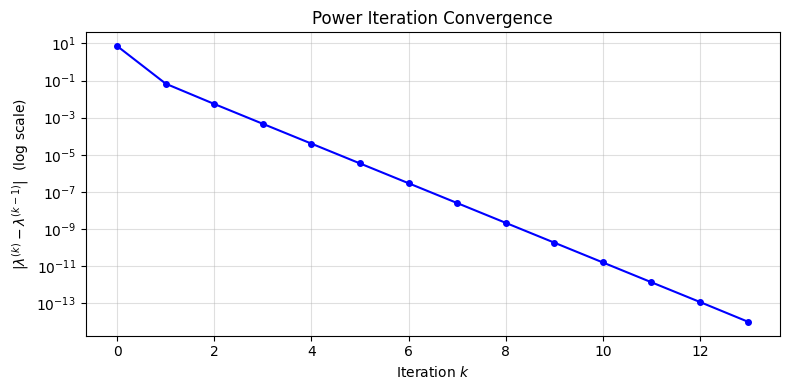

## 3. Inverse Power Iteration (Shifted)

To find the eigenvalue **closest to a shift** $\mu$, apply power iteration to $(A - \mu I)^{-1}$:

$$\text{If } A v = \lambda v, \text{ then } (A - \mu I)^{-1} v = \frac{1}{\lambda - \mu} v$$

The dominant eigenvalue of $(A - \mu I)^{-1}$ corresponds to the eigenvalue of $A$ closest to $\mu$.

### Algorithm
$$x^{(k+1)} = \frac{(A - \mu I)^{-1} x^{(k)}}{\|(A - \mu I)^{-1} x^{(k)}\|_2}$$

Each step requires solving a linear system $(A - \mu I) y = x^{(k)}$ - implemented with LU decomposition.

### When to use it
- Finding the **smallest** eigenvalue (shift $\mu = 0$)
- Refining an eigenvalue when you have a good initial estimate
- Computing **all** eigenvalues one at a time via deflation

In [6]:
# Inverse power iteration: smallest eigenvalue (shift=0)
ip_solver = InversePowerIteration(A, shift=0.0, tol=1e-12, max_iter=200)
mu_min, v_min = ip_solver.solve()
print(f"Smallest eigenvalue: λ_min ≈ {mu_min:.8f}")
print(f"Eigenvector:         v ≈ {[round(vi, 6) for vi in v_min.data]}")

# Shifted: find eigenvalue near 3.5
ip_solver2 = InversePowerIteration(A, shift=3.5, tol=1e-12, max_iter=200)
mu2, v2 = ip_solver2.solve()
print(f"\nEigenvalue near 3.5: λ ≈ {mu2:.8f}")
print(f"Eigenvector:         v ≈ {[round(vi, 6) for vi in v2.data]}")

# Print trace
print("\nInverse Power Iteration Trace (first 8 steps):")
ip_solver.trace()

Smallest eigenvalue: λ_min ≈ 0.57893339
Eigenvector:         v ≈ [-0.043168, -0.350731, 0.935481]

Eigenvalue near 3.5: λ ≈ 2.13307448
Eigenvector:         v ≈ [0.497425, -0.819589, -0.284328]

Inverse Power Iteration Trace (first 8 steps):
Inverse/Shifted Power Iteration Trace
  iter |           mu |        error
----------------------------------------
     0 | 1.000000e+00 |          inf
     1 | 5.915493e-01 | 4.084507e-01
     2 | 5.797254e-01 | 1.182385e-02
     3 | 5.789909e-01 | 7.345960e-04
     4 | 5.789376e-01 | 5.323948e-05
     5 | 5.789337e-01 | 3.916209e-06
     6 | 5.789334e-01 | 2.884418e-07
     7 | 5.789334e-01 | 2.124706e-08
     8 | 5.789334e-01 | 1.565105e-09
     9 | 5.789334e-01 | 1.152891e-10
    10 | 5.789334e-01 | 8.492540e-12
    11 | 5.789334e-01 | 6.254997e-13


## 4. Rayleigh Quotient Iteration

**Rayleigh Quotient Iteration (RQI)** adapts the shift at each iteration using the current Rayleigh quotient:

$$\mu^{(k)} = \frac{(x^{(k)})^T A x^{(k)}}{(x^{(k)})^T x^{(k)}}$$

then solves $(A - \mu^{(k)} I) y = x^{(k)}$.

### Convergence: Cubic!
RQI converges **cubically** once near an eigenvalue - errors cube at each step (e.g., $10^{-3} \to 10^{-9} \to 10^{-27}$).

This makes it the **fastest** single-eigenvalue method, but it:
- Can converge to **any** eigenvalue depending on the starting guess
- Requires solving a linear system per step (shifting makes $A - \mu I$ potentially ill-conditioned near convergence)

In [7]:
rqi_solver = RayleighQuotientIteration(A, tol=1e-14, max_iter=50)
mu_rqi, v_rqi = rqi_solver.solve()

print(f"RQI eigenvalue:  λ ≈ {mu_rqi:.12f}")
print(f"Converged in:    {len(rqi_solver.history)} iterations")
print()

# Compare convergence speed
print("=== Convergence Comparison ===")
print(f"{'Iter':>5} | {'Power Iter error':>18} | {'RQI error':>12}")
print("-" * 42)

rqi_errs = [h['error'] for h in rqi_solver.history]
pi_errs  = [h['error'] for h in pi_solver2.history]

n = min(len(rqi_errs), 10)
for k in range(n):
    pi_err = pi_errs[k] if k < len(pi_errs) else float('nan')
    rq_err = rqi_errs[k]
    print(f"{k:5d} | {pi_err:18.6e} | {rq_err:12.6e}")

print("\nRQI reaches machine precision ~3x faster (cubic vs linear convergence).")

RQI eigenvalue:  λ ≈ 7.287992138960
Converged in:    4 iterations

=== Convergence Comparison ===
 Iter |   Power Iter error |    RQI error
------------------------------------------
    0 |       7.214286e+00 | 1.153846e+00
    1 |       6.773063e-02 | 1.340620e-01
    2 |       5.465998e-03 | 8.397528e-05
    3 |       4.661343e-04 | 2.131628e-14

RQI reaches machine precision ~3x faster (cubic vs linear convergence).


## 5. QR Eigenvalue Algorithm

The **QR iteration** computes **all eigenvalues** simultaneously.

### Algorithm
1. Start with $A_0 = A$
2. Compute QR factorization: $A_k = Q_k R_k$
3. Form $A_{k+1} = R_k Q_k$

As $k \to \infty$, $A_k$ converges to a **quasi-upper triangular** (Schur) form, with the eigenvalues appearing on the diagonal.

### Why does this work?
$A_{k+1} = R_k Q_k = Q_k^T A_k Q_k$  each step is an **orthogonal similarity transformation** that preserves eigenvalues.

### Notes on `numethods` implementation
- `QREigenvalues` implements the **basic unshifted** QR iteration
- Production codes (LAPACK) use shifts and deflation for speed
- The method is $O(n^3)$ per iteration and requires many iterations

In [8]:
# QR eigenvalue iteration
A_sym = Matrix([[6, 2, 1],
                [2, 3, 1],
                [1, 1, 1]])

qr_eig = QREigenvalues(A_sym, tol=1e-10, max_iter=5000)
A_schur = qr_eig.solve()

print("Schur form (approximately upper triangular):")
for row in A_schur.data:
    print("  ", [round(x, 6) for x in row])

eigenvalues = [round(A_schur.data[i][i], 8) for i in range(A_schur.n)]
print(f"\nEigenvalues from QR iteration: {eigenvalues}")

# Cross-verify with power/inverse power:
print(f"\nDominant eigenvalue (Power Iter): {round(lam, 8)}")
print(f"Min eigenvalue (Inverse Power):   {round(mu_min, 8)}")
print(f"Sum of eigenvalues (= trace(A)):  {sum(eigenvalues):.6f}")
print(f"Trace of A:                       {sum(A_sym.data[i][i] for i in range(A_sym.n)):.6f}")

Schur form (approximately upper triangular):
   [7.287992, 0.0, 0.0]
   [0.0, 2.133074, 0.0]
   [0.0, 0.0, 0.578933]

Eigenvalues from QR iteration: [7.28799214, 2.13307448, 0.57893339]

Dominant eigenvalue (Power Iter): 7.28799214
Min eigenvalue (Inverse Power):   0.57893339
Sum of eigenvalues (= trace(A)):  10.000000
Trace of A:                       10.000000


## 6. Singular Value Decomposition (SVD)

For **any** matrix $A \in \mathbb{R}^{m \times n}$ (not necessarily square), the SVD is:

$$A = U \Sigma V^T$$

where:
- $U \in \mathbb{R}^{m \times m}$: **left singular vectors** (orthonormal columns)
- $\Sigma \in \mathbb{R}^{m \times n}$: diagonal with **singular values** $\sigma_1 \geq \sigma_2 \geq \ldots \geq 0$
- $V \in \mathbb{R}^{n \times n}$: **right singular vectors** (orthonormal columns)

### Connection to eigenvalues
$$A^T A = V \Sigma^T \Sigma V^T \quad \Rightarrow \quad \sigma_i = \sqrt{\lambda_i(A^T A)}$$

The `numethods` `SVD` class uses this eigen-decomposition of $A^T A$.

### Applications
- **Pseudoinverse**: $A^+ = V \Sigma^+ U^T$ (solving ill-posed systems)
- **Low-rank approximation**: keep top $r$ singular values
- **PCA**: SVD of the data matrix
- **Condition number**: $\kappa_2(A) = \sigma_1 / \sigma_n$
- **Rank determination**: count non-zero singular values

In [12]:
# SVD of a rectangular matrix
M = Matrix([[3.0, 1.0, 0.0],
            [1.0, 3.0, 1.0],
            [0.0, 1.0, 2.0],
            [1.0, 0.0, 1.0]])   # 4 x 3

U, sigma, V = SVD(M).solve()

print(f"A shape: {M.m} x {M.n}")
print(f"Singular values σ: {[round(s, 6) for s in sigma.data]}")
print(f"U shape: {U.m} x {U.n}")
print(f"V shape: {V.m} x {V.n}")

# Verify: U^T U ≈ I
UtU = U.T @ U
print("\nU^T U:")
for row in UtU.data:
    print("  ", [round(x, 4) for x in row])

# Verify: V^T V ≈ I
VtV = V.T @ V
print("\nV^T V:")
for row in VtV.data:
    print("  ", [round(x, 4) for x in row])

A shape: 4 x 3
Singular values σ: [4.352189, 2.559848, 1.582917]
U shape: 4 x 3
V shape: 3 x 3

U^T U:
   [1.0, 0.0, -0.0]
   [0.0, 1.0, 0.0]
   [-0.0, 0.0, 1.0]

V^T V:
   [1.0, -0.0, -0.0]
   [-0.0, 1.0, -0.0]
   [-0.0, -0.0, 1.0]


In [24]:
# Verify reconstruction: A ≈ U Σ V^T
import math

def build_sigma_matrix(sigma, m, n):
    """Build the full Sigma matrix from singular values."""
    S = Matrix([[0.0]*n for _ in range(m-1)])
    for i in range(min(m, n)):
        S.data[i][i] = sigma[i]
    return S

Sigma_mat = build_sigma_matrix(sigma, M.m, M.n)
A_reconstructed = U @ Sigma_mat @ V.T

print("Original A:")
for row in M.data:
    print("  ", [round(x, 4) for x in row])

print("\nReconstructed U Σ V^T:")
for row in A_reconstructed.data:
    print("  ", [round(x, 4) for x in row])

# Frobenius error
err = sum((M.data[i][j] - A_reconstructed.data[i][j])**2 
          for i in range(M.m) for j in range(M.n)) ** 0.5
print(f"\nFrobenius reconstruction error: {err:.2e}")

Original A:
   [3.0, 1.0, 0.0]
   [1.0, 3.0, 1.0]
   [0.0, 1.0, 2.0]
   [1.0, 0.0, 1.0]

Reconstructed U Σ V^T:
   [3.0, 1.0, 0.0]
   [1.0, 3.0, 1.0]
   [0.0, 1.0, 2.0]
   [1.0, 0.0, 1.0]

Frobenius reconstruction error: 3.93e-14


## 7. Low-Rank Approximation

One of the most powerful applications of SVD is **data compression** via low-rank approximation.

**Eckart–Young Theorem:** Among all rank-$r$ matrices $B$, the best approximation to $A$ in the Frobenius norm is:

$$A_r = \sum_{i=1}^{r} \sigma_i u_i v_i^T, \quad \|A - A_r\|_F = \sqrt{\sigma_{r+1}^2 + \cdots + \sigma_k^2}$$

This has direct applications in:
- **Geophysical inversion**: regularize ill-posed problems via rank truncation
- **Seismic data processing**: noise suppression via SVD filtering
- **Image compression**: keep top-r singular values

In [25]:
# Low-rank approximation demonstration
# Build a "data matrix" = true signal + noise
import random
random.seed(7)

m, n = 8, 6
# True rank-2 matrix: outer products of vectors
u1 = [math.sin(i*math.pi/7) for i in range(m)]
u2 = [math.cos(i*math.pi/7) for i in range(m)]
v1 = [1.0/(j+1) for j in range(n)]
v2 = [(-1)**j * 1.0/(j+1) for j in range(n)]

true_A = Matrix([[3*u1[i]*v1[j] + 1.5*u2[i]*v2[j] for j in range(n)] for i in range(m)])

# Add noise
noise_scale = 0.3
noisy_A = Matrix([[true_A.data[i][j] + random.gauss(0, noise_scale) 
                   for j in range(n)] for i in range(m)])

# Compute SVD of noisy matrix
U_n, sigma_n, V_n = SVD(noisy_A).solve()
print("Singular values of noisy A:")
for k, s in enumerate(sigma_n.data):
    print(f"  σ_{k+1} = {s:.4f}")

# Reconstruct at ranks 1, 2, 3
print("Reconstruction errors (Frobenius norm):")
def frob_err(A, B):
    return sum((A.data[i][j] - B.data[i][j])**2 
               for i in range(A.m) for j in range(A.n)) ** 0.5

for r in [1, 2, 3, 4]:
    # Build rank-r approximation
    Ar = Matrix([[0.0]*n for _ in range(m)])
    for k in range(r):
        uk = U_n.col(k)
        vk = V_n.col(k)
        sig = sigma_n[k]
        for i in range(m):
            for j in range(n):
                Ar.data[i][j] += sig * uk[i] * vk[j]
    
    err_noisy = frob_err(noisy_A, Ar)
    err_true  = frob_err(true_A, Ar)
    print(f"  Rank-{r}: err vs noisy = {err_noisy:.4f},  err vs true = {err_true:.4f}")

print("→ Rank-2 approximation recovers the true rank-2 structure best!")

Singular values of noisy A:
  σ_1 = 7.1291
  σ_2 = 3.0888
  σ_3 = 1.0358
  σ_4 = 0.5636
  σ_5 = 0.2399
  σ_6 = 0.1072
Reconstruction errors (Frobenius norm):
  Rank-1: err vs noisy = 3.3166,  err vs true = 3.2032
  Rank-2: err vs noisy = 1.2081,  err vs true = 1.2984
  Rank-3: err vs noisy = 0.6219,  err vs true = 1.6611
  Rank-4: err vs noisy = 0.2628,  err vs true = 1.7450
→ Rank-2 approximation recovers the true rank-2 structure best!


## 8. Summary

| Method | Finds | Convergence | Cost/iter |
|--------|-------|-------------|-----------|
| **Power Iteration** | Dominant eigenvalue | Linear |$\lambda_2/\lambda_1|^k$ | $O(n^2)$ |
| **Inverse Power** | Eigenvalue nearest shift $\mu$ | Linear | $O(n^3)$ (LU solve) |
| **Rayleigh Quotient** | One eigenvalue (nearest to $x^{(0)}$) | **Cubic** | $O(n^3)$ (LU solve) |
| **QR Iteration** | **All** eigenvalues | Linear (can be accelerated) | $O(n^3)$/iter |
| **SVD** | Singular values + vectors | Via eigenvalues of $A^TA$ | $O(n^3)$ |

### Key identities
$$\sum_i \lambda_i = \text{tr}(A), \quad \prod_i \lambda_i = \det(A)$$
$$\kappa_2(A) = \frac{\sigma_{\max}}{\sigma_{\min}}, \quad \|A\|_2 = \sigma_{\max}(A)$$

### Exercises
1. Show that the eigenvalues of $A^{-1}$ are $1/\lambda_i$ (this justifies inverse power iteration).
2. Use `PowerIteration` on a matrix with two equal dominant eigenvalues. What happens?
3. Compute the **condition number** of the Hilbert matrix $H_{ij} = 1/(i+j-1)$ for $n=3,4,5$ using `SVD` and observe rapid growth.
4. Apply SVD to a $10 \times 5$ data matrix of your choice and plot the singular value decay.
5. Use `RayleighQuotientIteration` starting from a random initial vector. Does it always converge to the same eigenvalue?